<a href="https://colab.research.google.com/github/Priya-DharshiniRamesh/24ADI006_DEEP-LEARNING/blob/main/DL_EXP_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**DEEP LEARNING -24ADI006**

**EXPT NO: 3 -	IMPLEMENTATION OF CONVOLUTIONAL NEURAL NETWORKS (CNNs) FOR IMAGE CLASSIFICATION**

**Name:Priya Dharshini R**\
**Roll No:24BAD092**

**AIM**

To design, implement, and evaluate a Convolutional Neural Network (CNN) for image classification using a benchmark image dataset.

**SOFTWARE REQUIREMENTS**

•	Python

•	TensorFlow/Keras or PyTorch

•	Google Colab

•	Matplotlib

•	Kaggle Dataset (e.g., CIFAR-10, Cats vs Dogs, Intel Image Classification)

**OBJECTIVES**

Students will be able to:

•	Understand the architecture of Convolutional Neural Networks.

•	Implement a CNN model for image classification.

•	Train and evaluate a CNN using a real-world image dataset.

•	Visualize training and validation performance.

•	Analyze the effectiveness of CNNs for image recognition tasks.


**Task A: DATASET PREPARATION**

•	Perform the following tasks:

•	Download an image dataset from Kaggle or use CIFAR-10.

•	Load the dataset.

•	Preprocess images by resizing and normalization.

•	Split the dataset into training, validation, and testing sets.


Priya Dharshini R
24BAD092
Task A: Dataset Preparation

Dataset Information
Training data shape   : (40000, 32, 32, 3)
Validation data shape : (10000, 32, 32, 3)
Testing data shape    : (10000, 32, 32, 3)


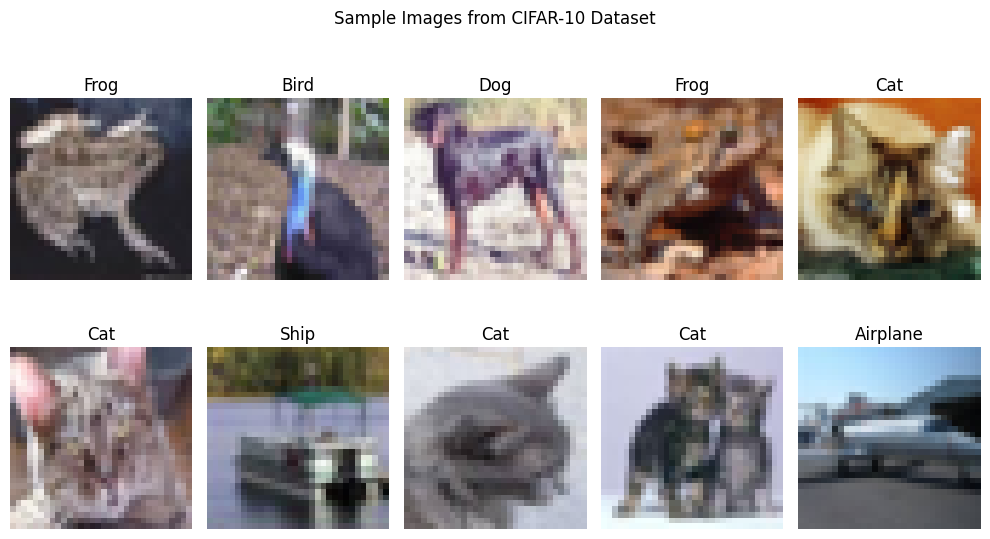


Task A completed successfully.


In [ ]:
# Task A: Dataset Preparation

import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

print("Priya Dharshini R")
print("24BAD092")
print("Task A: Dataset Preparation")

# 1. Load CIFAR-10 dataset
(X_train_full, y_train_full), (X_test, y_test) = cifar10.load_data()

# CIFAR-10 class names
class_names = [
    'Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
    'Dog', 'Frog', 'Horse', 'Ship', 'Truck'
]

# 2. Normalize image pixel values from 0-255 to 0-1
X_train_full = X_train_full.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# 3. Split training data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=42
)

# 4. Flatten labels
y_train = y_train.flatten()
y_val = y_val.flatten()
y_test = y_test.flatten()

# 5. Display dataset shapes
print("\nDataset Information")
print("Training data shape   :", X_train.shape)
print("Validation data shape :", X_val.shape)
print("Testing data shape    :", X_test.shape)

# 6. Display sample images
plt.figure(figsize=(10, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.suptitle("Sample Images from CIFAR-10 Dataset")
plt.tight_layout()
plt.show()

print("\nTask A completed successfully.")

**Task B: CNN MODEL IMPLEMENTATION**

**Build a CNN model consisting of:**

•	Convolution layers

•	ReLU activation

•	Max Pooling layers

•	Fully Connected layers

•	Softmax output layer

**Compile the model using:**

•	Appropriate optimizer

•	Cross-entropy loss function



In [ ]:
# Task B: CNN Model Implementation

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense

print("Priya Dharshini R")
print("24BAD092")
print("Task B: CNN Model Implementation")

# Build CNN model
cnn_model = Sequential([

    # Input layer
    Input(shape=(32, 32, 3)),

    # First convolution and pooling
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Second convolution and pooling
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Third convolution
    Conv2D(64, (3, 3), activation='relu'),

    # Fully connected layers
    Flatten(),
    Dense(64, activation='relu'),

    # Output layer with Softmax
    Dense(10, activation='softmax')
])

# Compile the model
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
cnn_model.summary()

print("\nTask B completed successfully.")
print("Optimizer: Adam")
print("Loss Function: Sparse Categorical Cross-Entropy")
print("Output Activation: Softmax")

Priya Dharshini R
24BAD092
Task B: CNN Model Implementation


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)


Task B completed successfully.
Optimizer: Adam
Loss Function: Sparse Categorical Cross-Entropy
Output Activation: Softmax


 **Task C: MODEL TRAINING AND EVALUATION
Train the CNN model.**

**Record:**

•	Training accuracy

•	Validation accuracy

•	Training loss

•	Validation loss

•	Testing accuracy

**Plot:**

•	Accuracy vs Epoch

•	Loss vs Epoch



Priya Dharshini R
24BAD092
Task C: Model Training and Evaluation

Starting CNN training...
Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 66s 89ms/step - accuracy: 0.3911 - loss: 1.6619 - val_accuracy: 0.5011 - val_loss: 1.3604
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 90ms/step - accuracy: 0.5333 - loss: 1.3005 - val_accuracy: 0.5786 - val_loss: 1.1997
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 80s 87ms/step - accuracy: 0.5932 - loss: 1.1543 - val_accuracy: 0.6065 - val_loss: 1.1151
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 87ms/step - accuracy: 0.6280 - loss: 1.0547 - val_accuracy: 0.6277 - val_loss: 1.0494
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 86ms/step - accuracy: 0.6557 - loss: 0.9787 - val_accuracy: 0.6430 - val_loss: 1.0199
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 86ms/step - accuracy: 0.6835 - loss: 0.9094 - val_accuracy: 0.6725 - val_loss: 0.9481
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 86ms/step - accuracy: 0.7002 - loss: 0.8538 - val_accuracy: 0.6749 - val_loss: 0.9186

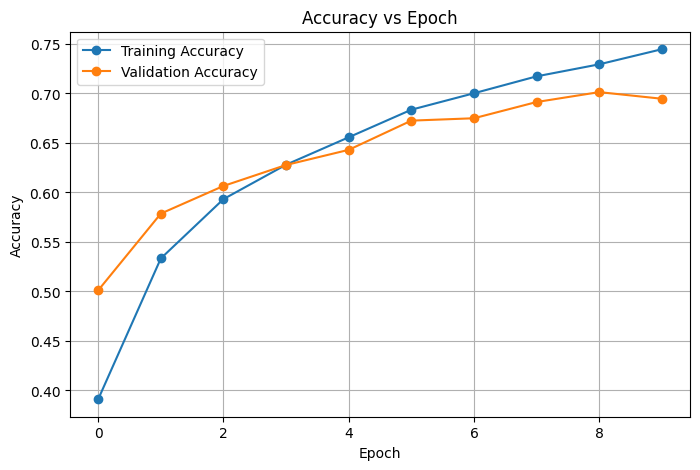

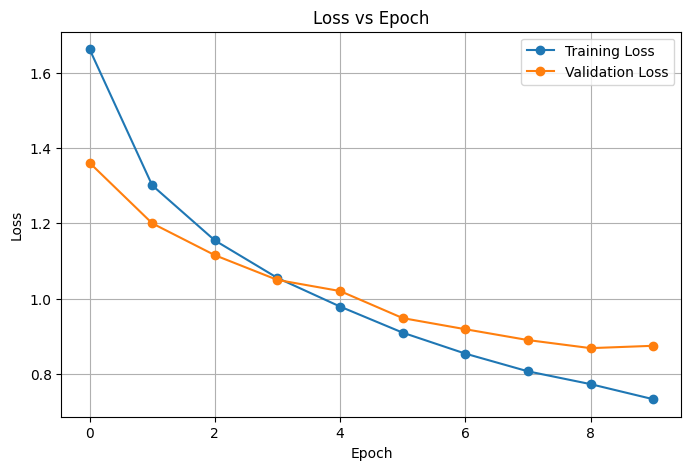


Task C completed successfully.


In [ ]:
# Task C: Model Training and Evaluation

import matplotlib.pyplot as plt

print("Priya Dharshini R")
print("24BAD092")
print("Task C: Model Training and Evaluation")

# Train the CNN model
print("\nStarting CNN training...")

history = cnn_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=1
)

# Evaluate the model on the test dataset
print("\nEvaluating CNN on Test Set...")

test_loss, test_accuracy = cnn_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

# Display final results
print("\nFinal Model Results")
print(f"Training Accuracy   : {history.history['accuracy'][-1]:.4f}")
print(f"Validation Accuracy : {history.history['val_accuracy'][-1]:.4f}")
print(f"Training Loss       : {history.history['loss'][-1]:.4f}")
print(f"Validation Loss     : {history.history['val_loss'][-1]:.4f}")
print(f"Testing Accuracy    : {test_accuracy:.4f}")
print(f"Testing Loss        : {test_loss:.4f}")

# Plot Accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy',
    marker='o'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy',
    marker='o'
)

plt.title('Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot Loss
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss',
    marker='o'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss',
    marker='o'
)

plt.title('Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

print("\nTask C completed successfully.")

**Task D: PERFORMANCE ANALYSIS**

**Analyze:**

•	Classification accuracy

•	Confusion Matrix

•	Sample predictions

•	Misclassified images

Discuss the strengths and limitations of CNNs for image classification.


Priya Dharshini R
24BAD092
Task D: Performance Analysis

Generating predictions...


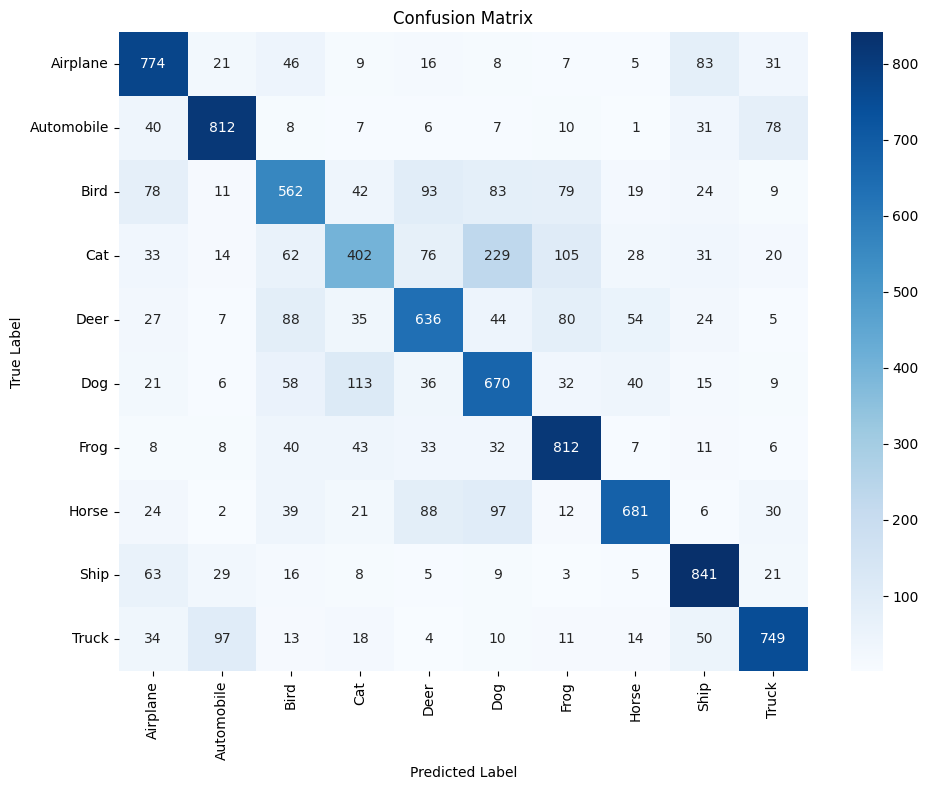


Classification Report
              precision    recall  f1-score   support

    Airplane       0.70      0.77      0.74      1000
  Automobile       0.81      0.81      0.81      1000
        Bird       0.60      0.56      0.58      1000
         Cat       0.58      0.40      0.47      1000
        Deer       0.64      0.64      0.64      1000
         Dog       0.56      0.67      0.61      1000
        Frog       0.71      0.81      0.75      1000
       Horse       0.80      0.68      0.73      1000
        Ship       0.75      0.84      0.79      1000
       Truck       0.78      0.75      0.77      1000

    accuracy                           0.69     10000
   macro avg       0.69      0.69      0.69     10000
weighted avg       0.69      0.69      0.69     10000


Correct Predictions


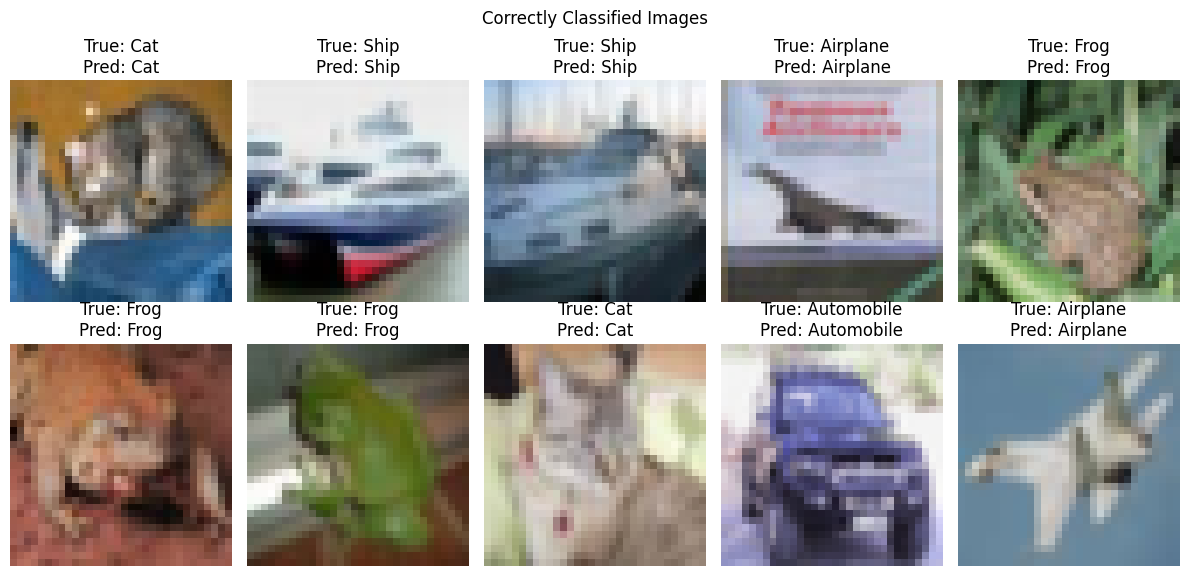


Misclassified Images


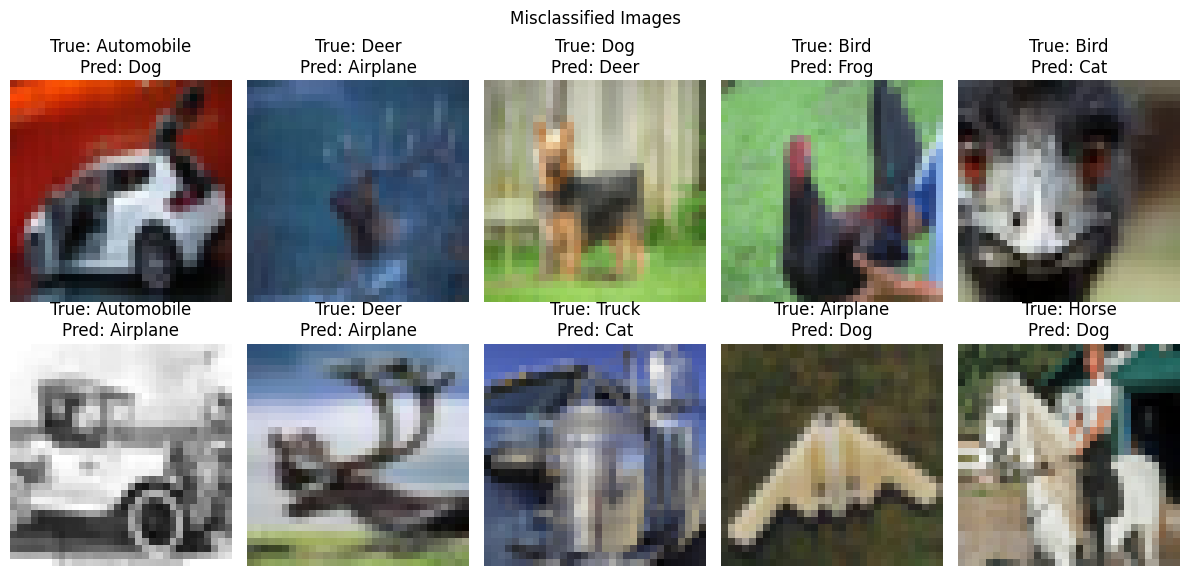


Performance Analysis
Total Test Images       : 10000
Correct Predictions     : 6939
Misclassified Images    : 3061
Testing Accuracy        : 0.6939

Strengths of CNNs:
1. CNNs automatically learn important image features.
2. Convolution layers detect edges, textures and patterns.
3. Pooling reduces the spatial size of feature maps.
4. CNNs are effective for image classification tasks.

Limitations of CNNs:
1. CNNs may require large amounts of training data.
2. Training can require considerable computational resources.
3. CNNs can suffer from overfitting.
4. Similar-looking image classes can be difficult to distinguish.

Task D completed successfully.


In [ ]:
# Task D: Performance Analysis

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

print("Priya Dharshini R")
print("24BAD092")
print("Task D: Performance Analysis")

# Generate predictions
print("\nGenerating predictions...")

y_pred_prob = cnn_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# Classification report
print("\nClassification Report")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names
    )
)

# Find correct and incorrect predictions
correct_indices = np.where(y_pred == y_test)[0]
misclassified_indices = np.where(y_pred != y_test)[0]

# Display correct predictions
print("\nCorrect Predictions")

plt.figure(figsize=(12, 6))

for i in range(min(10, len(correct_indices))):
    idx = correct_indices[i]

    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[idx])
    plt.title(
        f"True: {class_names[y_test[idx]]}\n"
        f"Pred: {class_names[y_pred[idx]]}"
    )
    plt.axis('off')

plt.suptitle("Correctly Classified Images")
plt.tight_layout()
plt.show()

# Display misclassified images
print("\nMisclassified Images")

plt.figure(figsize=(12, 6))

for i in range(min(10, len(misclassified_indices))):
    idx = misclassified_indices[i]

    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[idx])
    plt.title(
        f"True: {class_names[y_test[idx]]}\n"
        f"Pred: {class_names[y_pred[idx]]}"
    )
    plt.axis('off')

plt.suptitle("Misclassified Images")
plt.tight_layout()
plt.show()

# Performance summary
print("\nPerformance Analysis")

print(f"Total Test Images       : {len(y_test)}")
print(f"Correct Predictions     : {len(correct_indices)}")
print(f"Misclassified Images    : {len(misclassified_indices)}")
print(f"Testing Accuracy        : {len(correct_indices) / len(y_test):.4f}")

print("\nStrengths of CNNs:")
print("1. CNNs automatically learn important image features.")
print("2. Convolution layers detect edges, textures and patterns.")
print("3. Pooling reduces the spatial size of feature maps.")
print("4. CNNs are effective for image classification tasks.")

print("\nLimitations of CNNs:")
print("1. CNNs may require large amounts of training data.")
print("2. Training can require considerable computational resources.")
print("3. CNNs can suffer from overfitting.")
print("4. Similar-looking image classes can be difficult to distinguish.")

print("\nTask D completed successfully.")